# LightGCL: Simple Yet Effective Graph Contrastive Learning for Recommendation

## Paper

LightGCL: Simple Yet Effective Graph Contrastive Learning for Recommendation

Published at SIGIR 2023

---

## Objective

Implement LightGCL from scratch using MovieLens-100K.

Unlike SimGCL and XSimGCL, LightGCL constructs the second contrastive view from the graph's **spectral information** instead of random perturbations.

---

## Pipeline

MovieLens

↓

Interaction Graph

↓

Normalized Laplacian

↓

Top-k Eigenvectors

↓

Spectral Embeddings

↓

LightGCN Encoder

↓

Contrastive Learning

↓

Bayesian Personalized Ranking

↓

Recommendation

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import scipy.sparse as sp

# ⭐ NEW
from scipy.sparse.linalg import eigsh

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    roc_curve
)

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader
)

torch.manual_seed(42)
np.random.seed(42)

In [3]:
# Load ratings dataset

ratings = pd.read_csv(
    "../data/u.data",
    sep="\t",
    names=[
        "user_id",
        "movie_id",
        "rating",
        "timestamp"
    ]
)

ratings.head()

,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [4]:
print("Ratings Shape :", ratings.shape)

print("\nMissing Values")

print(ratings.isnull().sum())

print("\nUnique Users :", ratings["user_id"].nunique())

print("Unique Movies :", ratings["movie_id"].nunique())

Ratings Shape : (100000, 4)

Missing Values
user_id      0
movie_id     0
rating       0
timestamp    0
dtype: int64

Unique Users : 943
Unique Movies : 1682


In [5]:
ratings.describe()

,user_id,movie_id,rating,timestamp
count,100000.00000,100000.000000,100000.000000,1.000000e+05
mean,462.48475,425.530130,3.529860,8.835289e+08
std,266.61442,330.798356,1.125674,5.343856e+06
min,1.00000,1.000000,1.000000,8.747247e+08
25%,254.00000,175.000000,3.000000,8.794487e+08
50%,447.00000,322.000000,4.000000,8.828269e+08
75%,682.00000,631.000000,4.000000,8.882600e+08
max,943.00000,1682.000000,5.000000,8.932866e+08


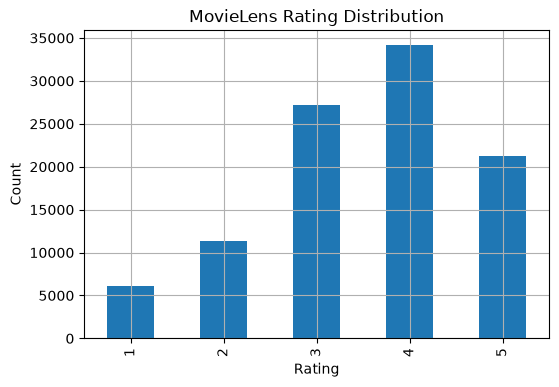

In [6]:
plt.figure(figsize=(6,4))

ratings["rating"].value_counts().sort_index().plot(
    kind="bar"
)

plt.xlabel("Rating")

plt.ylabel("Count")

plt.title("MovieLens Rating Distribution")

plt.grid(True)

plt.show()

In [ ]:
# Positive interaction = user rated the movie with 4 stars or more.
# This gives us a meaningful binary label so that TOP@k metrics
# (Precision@k, Recall@k, NDCG@k, ...) are interpretable:
# a "hit" is a test item the user actually liked.
ratings["label"] = (ratings["rating"] >= 4).astype(int)

ratings.head()

In [8]:
user_mapping = {
    u:i
    for i, u in enumerate(
        ratings["user_id"].unique()
    )
}

movie_mapping = {
    m:i
    for i, m in enumerate(
        ratings["movie_id"].unique()
    )
}

ratings["user_id"] = ratings["user_id"].map(
    user_mapping
)

ratings["movie_id"] = ratings["movie_id"].map(
    movie_mapping
)

ratings.head()

,user_id,movie_id,rating,timestamp,label
0,0,0,3,881250949,1
1,1,1,3,891717742,1
2,2,2,1,878887116,1
3,3,3,2,880606923,1
4,4,4,1,886397596,1


In [9]:
NUM_USERS = ratings["user_id"].nunique()

NUM_MOVIES = ratings["movie_id"].nunique()

NUM_NODES = NUM_USERS + NUM_MOVIES

print("Users :", NUM_USERS)

print("Movies :", NUM_MOVIES)

print("Total Nodes :", NUM_NODES)

Users : 943
Movies : 1682
Total Nodes : 2625


In [ ]:
train_df, test_df = train_test_split(

    ratings,

    test_size=0.2,

    random_state=42,

    shuffle=True,

    stratify=ratings["label"]

)

train_df = train_df.reset_index(drop=True)

test_df = test_df.reset_index(drop=True)

print("Train :", train_df.shape)
print("Test  :", test_df.shape)
print()
print("Train label distribution:")
print(train_df["label"].value_counts(normalize=True))
print()
print("Test label distribution:")
print(test_df["label"].value_counts(normalize=True))

In [11]:
interaction = sp.coo_matrix(

    (

        np.ones(len(train_df)),

        (

            train_df["user_id"],

            train_df["movie_id"]

        )

    ),

    shape=(

        NUM_USERS,

        NUM_MOVIES

    )

)

interaction

<COOrdinate sparse matrix of dtype 'float64'
	with 80000 stored elements and shape (943, 1682)>

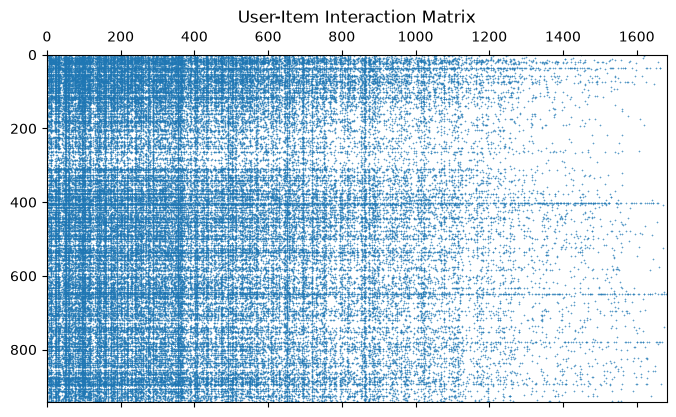

In [13]:
plt.figure(figsize=(8,6))

plt.spy(

    interaction,

    markersize=0.2

)

plt.title(

    "User-Item Interaction Matrix"

)

plt.show()

In [14]:
adjacency = sp.bmat(

    [

        [

            sp.csr_matrix(

                (

                    NUM_USERS,

                    NUM_USERS

                )

            ),

            interaction

        ],

        [

            interaction.T,

            sp.csr_matrix(

                (

                    NUM_MOVIES,

                    NUM_MOVIES

                )

            )

        ]

    ],

    format="csr"

)

adjacency

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 160000 stored elements and shape (2625, 2625)>

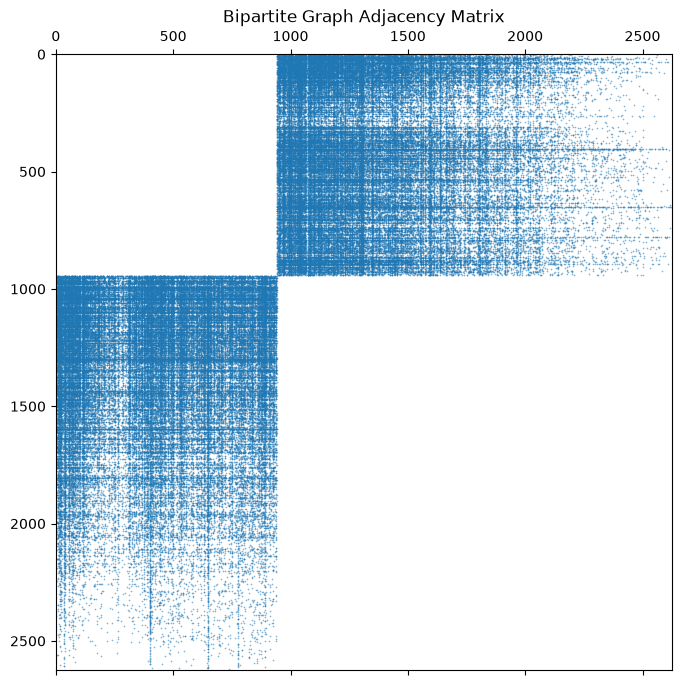

In [15]:
plt.figure(figsize=(8,8))

plt.spy(

    adjacency,

    markersize=0.15

)

plt.title(

    "Bipartite Graph Adjacency Matrix"

)

plt.show()

In [16]:
degree = np.array(

    adjacency.sum(axis=1)

).flatten()

degree

array([ 29.,  69., 101., ...,   0.,   1.,   0.], shape=(2625,))

In [17]:
print("Minimum Degree :", degree.min())

print("Maximum Degree :", degree.max())

print("Average Degree :", degree.mean())

Minimum Degree : 0.0
Maximum Degree : 578.0
Average Degree : 60.95238095238095


In [18]:
degree_inv_sqrt = np.power(

    degree,

    -0.5

)

degree_inv_sqrt[

    np.isinf(

        degree_inv_sqrt

    )

] = 0

D_inv_sqrt = sp.diags(

    degree_inv_sqrt
)

In [19]:
normalized_graph = (

    D_inv_sqrt

    @

    adjacency

    @

    D_inv_sqrt

)

normalized_graph

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 160000 stored elements and shape (2625, 2625)>

In [20]:
identity = sp.eye(

    NUM_NODES,

    format="csr"

)

laplacian = (

    identity

    -

    normalized_graph

)

laplacian

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 162625 stored elements and shape (2625, 2625)>

In [21]:
print(

    "Shape :",

    laplacian.shape

)

print(

    "Non-zero Entries :",

    laplacian.nnz

)

print(

    "Density :",

    laplacian.nnz /

    (NUM_NODES**2)

)

Shape : (2625, 2625)
Non-zero Entries : 162625
Density : 0.02360090702947846


In [22]:
NUM_EIGENVECTORS = 64

eigenvalues, eigenvectors = eigsh(

    laplacian,

    k=NUM_EIGENVECTORS,

    which="SM"

)

In [23]:
print(

    eigenvalues
)

[-2.21625525e-16  3.49137981e-01  5.02497565e-01  5.39313742e-01
  5.87465775e-01  6.23981568e-01  6.40289726e-01  6.48099375e-01
  6.51939804e-01  6.57776409e-01  6.71551583e-01  6.80972476e-01
  6.91366667e-01  6.95715624e-01  7.05241132e-01  7.08494690e-01
  7.16851596e-01  7.22030416e-01  7.24212215e-01  7.27449201e-01
  7.31012005e-01  7.34223617e-01  7.36532742e-01  7.39690778e-01
  7.41985843e-01  7.43939259e-01  7.45748589e-01  7.46787917e-01
  7.48856016e-01  7.52016277e-01  7.53262131e-01  7.55556424e-01
  7.58004280e-01  7.58876357e-01  7.60838500e-01  7.62530038e-01
  7.64205422e-01  7.65865295e-01  7.66625330e-01  7.67899002e-01
  7.69594628e-01  7.70306076e-01  7.71983079e-01  7.72160425e-01
  7.73604786e-01  7.74415460e-01  7.75743366e-01  7.77125386e-01
  7.77786313e-01  7.80937159e-01  7.81295908e-01  7.82046613e-01
  7.82432994e-01  7.83070125e-01  7.84163357e-01  7.84326319e-01
  7.85845340e-01  7.87231110e-01  7.88068274e-01  7.88666376e-01
  7.89510478e-01  7.90180

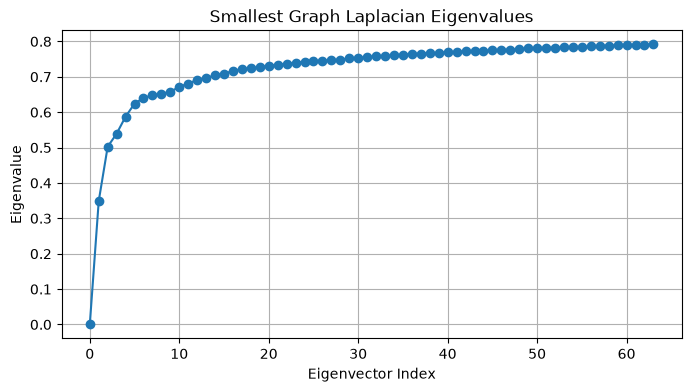

In [24]:
plt.figure(

    figsize=(8,4)

)

plt.plot(

    eigenvalues,

    marker="o"

)

plt.xlabel(

    "Eigenvector Index"

)

plt.ylabel(

    "Eigenvalue"

)

plt.title(

    "Smallest Graph Laplacian Eigenvalues"

)

plt.grid(True)

plt.show()

In [25]:
print(

    eigenvectors.shape
)

(2625, 64)


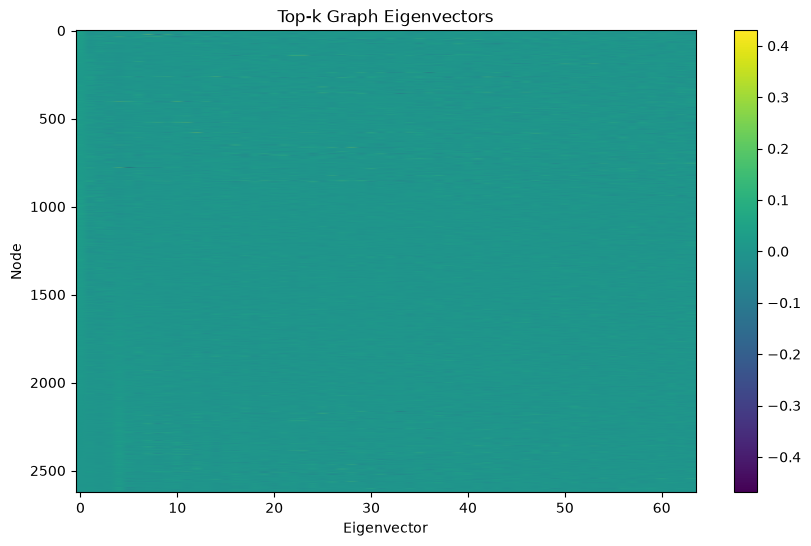

In [26]:
plt.figure(

    figsize=(10,6)

)

plt.imshow(

    eigenvectors,

    aspect="auto",

    cmap="viridis"

)

plt.colorbar()

plt.title(

    "Top-k Graph Eigenvectors"

)

plt.xlabel(

    "Eigenvector"

)

plt.ylabel(

    "Node"

)

plt.show()

In [27]:
spectral_embedding = torch.tensor(

    eigenvectors,

    dtype=torch.float32

)

In [28]:
device = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else

    "cpu"

)

spectral_embedding = spectral_embedding.to(

    device
)

In [29]:
print(

    spectral_embedding.shape
)

torch.Size([2625, 64])


In [30]:
normalized_graph = normalized_graph.tocoo()

indices = torch.tensor(
    np.vstack(
        (
            normalized_graph.row,
            normalized_graph.col
        )
    ),
    dtype=torch.long
)

values = torch.tensor(
    normalized_graph.data,
    dtype=torch.float32
)

graph = torch.sparse_coo_tensor(
    indices,
    values,
    normalized_graph.shape
)

graph = graph.coalesce().to(device)

In [31]:
print(graph)

print()

print("Shape :", graph.shape)

print("Non-Zero :", graph._nnz())

tensor(indices=tensor([[   0,    0,    0,  ..., 2617, 2618, 2623],
                       [ 943, 1026, 1122,  ...,  650,  739,  650]]),
       values=tensor([0.0191, 0.0124, 0.0121,  ..., 0.0426, 0.0670, 0.0426]),
       size=(2625, 2625), nnz=160000, layout=torch.sparse_coo)

Shape : torch.Size([2625, 2625])
Non-Zero : 160000


In [33]:
class LightGCL(nn.Module):

    def __init__(

        self,

        num_users,

        num_items,

        embedding_dim=64,

        num_layers=3

    ):

        super().__init__()

        self.num_users = num_users

        self.num_items = num_items

        self.num_layers = num_layers

        self.embedding_dim = embedding_dim

        self.embedding = nn.Embedding(

            num_users + num_items,

            embedding_dim

        )

        nn.init.xavier_uniform_(

            self.embedding.weight
        )
        
    def propagate(

        self,

        graph

    ):

        embeddings = self.embedding.weight

        all_embeddings = [

            embeddings

        ]

        for _ in range(

            self.num_layers

        ):

            embeddings = torch.sparse.mm(

                graph,

                embeddings

            )

            all_embeddings.append(

                embeddings

            )

        all_embeddings = torch.stack(

            all_embeddings,

            dim=1

        )

        final_embedding = torch.mean(

            all_embeddings,

            dim=1

        )

        return final_embedding
    def forward(

        self,

        graph,

        spectral_embedding

    ):

        graph_embedding = self.propagate(

            graph

        )

        return (

            graph_embedding,

            spectral_embedding

        )

In [34]:
model = LightGCL(

    NUM_USERS,

    NUM_MOVIES,

    embedding_dim=64,

    num_layers=3

).to(device)

In [35]:
model

LightGCL(
  (embedding): Embedding(2625, 64)
)

In [36]:
graph_embedding, teacher_embedding = model(

    graph,

    spectral_embedding

)

In [37]:
print(

    graph_embedding.shape

)

print(

    teacher_embedding.shape
)

torch.Size([2625, 64])
torch.Size([2625, 64])


In [39]:
graph_embedding = F.normalize(

    graph_embedding,

    dim=1

)

teacher_embedding = F.normalize(

    teacher_embedding,

    dim=1

)

In [40]:
similarity = torch.matmul(

    graph_embedding,

    teacher_embedding.T

)

In [41]:
similarity.shape

torch.Size([2625, 2625])

In [43]:
temperature = 0.2

In [44]:
positive = torch.diag(

    similarity

)

In [45]:
positive = torch.exp(

    positive /

    temperature

)

all_scores = torch.exp(

    similarity /

    temperature

)

In [47]:
contrastive_loss = -torch.log(

    positive /

    all_scores.sum(

        dim=1

    )

).mean()

In [48]:
print(

    contrastive_loss.item()

)

1.943698525428772


In [49]:
def bpr_loss(

    embeddings,

    users,

    positive_items,

    negative_items

):

    user_embedding = embeddings[

        users

    ]

    positive_embedding = embeddings[

        NUM_USERS +

        positive_items

    ]

    negative_embedding = embeddings[

        NUM_USERS +

        negative_items

    ]

    positive_score = (

        user_embedding *

        positive_embedding

    ).sum(

        dim=1

    )

    negative_score = (

        user_embedding *

        negative_embedding

    ).sum(

        dim=1

    )

    return -torch.log(

        torch.sigmoid(

            positive_score -

            negative_score

        )

    ).mean()

In [50]:
lambda_ssl = 0.1

In [ ]:
# Demo: BPR loss for a single (user, positive, negative) triple
demo_users = torch.LongTensor([0, 1, 2]).to(device)
demo_pos   = torch.LongTensor([10, 20, 30]).to(device)
demo_neg   = torch.LongTensor([100, 200, 300]).to(device)

demo_bpr = bpr_loss(
    graph_embedding,
    demo_users,
    demo_pos,
    demo_neg
)

print(f"Demo BPR Loss : {demo_bpr.item():.4f}")

In [ ]:
demo_total_loss = (
    demo_bpr
    +
    lambda_ssl *
    contrastive_loss
)

print(f"Demo Total Loss : {demo_total_loss.item():.4f}")

In [53]:
optimizer = torch.optim.Adam(

    model.parameters(),

    lr=0.001

)

In [54]:
class BPRDataset(Dataset):

    def __init__(self, dataframe):

        self.users = dataframe["user_id"].values
        self.items = dataframe["movie_id"].values

        self.user_history = (
            dataframe
            .groupby("user_id")["movie_id"]
            .apply(set)
            .to_dict()
        )

    def __len__(self):

        return len(self.users)

    def __getitem__(self, index):

        user = self.users[index]
        positive = self.items[index]

        while True:

            negative = np.random.randint(NUM_MOVIES)

            if negative not in self.user_history[user]:
                break

        return (
            user,
            positive,
            negative
        )

In [55]:
train_dataset = BPRDataset(train_df)

train_loader = DataLoader(

    train_dataset,

    batch_size=1024,

    shuffle=True
)



In [ ]:
NUM_EPOCHS = 20

lambda_ssl = 0.1

loss_history = []

for epoch in range(NUM_EPOCHS):

    model.train()

    epoch_loss = 0

    for users, positives, negatives in train_loader:

        users = users.to(device)

        positives = positives.to(device)

        negatives = negatives.to(device)

        graph_embedding, teacher_embedding = model(

            graph,

            spectral_embedding

        )

        graph_embedding = F.normalize(
            graph_embedding,
            dim=1
        )

        teacher_embedding = F.normalize(
            teacher_embedding,
            dim=1
        )

        similarity = torch.matmul(

            graph_embedding,

            teacher_embedding.T

        )

        positive_score = torch.diag(

            similarity

        )

        positive_score = torch.exp(

            positive_score / 0.2

        )

        all_scores = torch.exp(

            similarity / 0.2

        )

        ssl_loss = -torch.log(

            positive_score /

            all_scores.sum(dim=1)

        ).mean()

        ranking_loss = bpr_loss(

            graph_embedding,

            users,

            positives,

            negatives

        )

        total_loss = (

            ranking_loss

            +

            lambda_ssl *

            ssl_loss

        )

        optimizer.zero_grad()

        total_loss.backward()

        optimizer.step()

        epoch_loss += total_loss.item()

    epoch_loss /= len(train_loader)

    loss_history.append(epoch_loss)

    print(

        f"Epoch {epoch+1:2d}/{NUM_EPOCHS}"

        f" | Loss = {epoch_loss:.4f}"

    )

Epoch  1/20 | Loss = 1.1381
Epoch  2/20 | Loss = 0.8999
Epoch  3/20 | Loss = 0.8631
Epoch  4/20 | Loss = 0.8528
Epoch  5/20 | Loss = 0.8489
Epoch  6/20 | Loss = 0.8472
Epoch  7/20 | Loss = 0.8461
Epoch  8/20 | Loss = 0.8451
Epoch  9/20 | Loss = 0.8451
Epoch 10/20 | Loss = 0.8433
Epoch 11/20 | Loss = 0.8442
Epoch 12/20 | Loss = 0.8440
Epoch 13/20 | Loss = 0.8432
Epoch 14/20 | Loss = 0.8418
Epoch 15/20 | Loss = 0.8422
Epoch 16/20 | Loss = 0.8428
Epoch 17/20 | Loss = 0.8427
Epoch 18/20 | Loss = 0.8423
Epoch 19/20 | Loss = 0.8417


In [ ]:
plt.figure(figsize=(7,4))

plt.plot(loss_history)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("LightGCL Training")

plt.grid(True)

plt.show()

In [ ]:
model.eval()

with torch.no_grad():

    final_embedding, _ = model(

        graph,

        spectral_embedding

    )

In [ ]:
def recommend(

    user_id,

    top_k=10

):

    user_embedding = final_embedding[
        user_id
    ]

    item_embedding = final_embedding[
        NUM_USERS:
    ]

    scores = torch.matmul(

        item_embedding,

        user_embedding

    )

    _, indices = torch.topk(

        scores,

        top_k

    )

    return indices.cpu().numpy()

In [ ]:
recommend(0)

In [ ]:
prediction_df = test_df.copy()

scores = []

model.eval()

with torch.no_grad():

    for row in prediction_df.itertuples():

        score = torch.dot(

            final_embedding[row.user_id],

            final_embedding[
                NUM_USERS +
                row.movie_id
            ]

        ).item()

        scores.append(score)

prediction_df["score"] = scores

In [ ]:
prediction_df["probability"] = (

    prediction_df["score"]

    -

    prediction_df["score"].min()

) / (

    prediction_df["score"].max()

    -

    prediction_df["score"].min()

)

In [ ]:
prediction_df["prediction"] = (

    prediction_df["probability"]

    >=

    0.5

).astype(int)

In [ ]:
accuracy = accuracy_score(

    prediction_df["label"],

    prediction_df["prediction"]

)

auc = roc_auc_score(

    prediction_df["label"],

    prediction_df["probability"]

)

print(f"Accuracy : {accuracy:.4f}")

print(f"AUC : {auc:.4f}")

In [ ]:
fpr, tpr, _ = roc_curve(

    prediction_df["label"],

    prediction_df["probability"]

)

plt.figure(figsize=(6,6))

plt.plot(

    fpr,

    tpr,

    label=f"AUC={auc:.3f}"

)

plt.plot(

    [0,1],

    [0,1],

    "--"

)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("LightGCL ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
def precision_at_k(
    prediction_df,
    k=10
):

    precisions = []

    grouped = prediction_df.groupby(
        "user_id"
    )

    for _, group in grouped:

        top_k = group.sort_values(
            "score",
            ascending=False
        ).head(k)

        precisions.append(
            top_k["label"].mean()
        )

    return float(np.mean(precisions))


def recall_at_k(
    prediction_df,
    k=10
):

    recalls = []

    grouped = prediction_df.groupby(
        "user_id"
    )

    for _, group in grouped:

        relevant = group["label"].sum()

        if relevant == 0:
            continue

        top_k = group.sort_values(
            "score",
            ascending=False
        ).head(k)

        hits = top_k["label"].sum()

        recalls.append(
            hits / relevant
        )

    return float(np.mean(recalls))


def hit_rate_at_k(
    prediction_df,
    k=10
):

    hits = []

    grouped = prediction_df.groupby(
        "user_id"
    )

    for _, group in grouped:

        top_k = group.sort_values(
            "score",
            ascending=False
        ).head(k)

        hits.append(
            top_k["label"].sum() > 0
        )

    return float(np.mean(hits))


def ndcg_at_k(
    prediction_df,
    k=10
):

    ndcgs = []

    grouped = prediction_df.groupby(
        "user_id"
    )

    for _, group in grouped:

        relevant = group["label"].sum()

        if relevant == 0:
            continue

        top_k = group.sort_values(
            "score",
            ascending=False
        ).head(k)

        gains = top_k["label"].values

        # Discount factor: log2(rank + 2)
        discounts = np.log2(
            np.arange(len(gains)) + 2
        )

        dcg = np.sum(
            gains / discounts
        )

        # Ideal DCG: all relevant items ranked at the top
        ideal_gains = np.ones(
            min(int(relevant), k)
        )

        idcg = np.sum(
            ideal_gains / np.log2(
                np.arange(len(ideal_gains)) + 2
            )
        )

        if idcg > 0:
            ndcgs.append(dcg / idcg)

    return float(np.mean(ndcgs))


def map_at_k(
    prediction_df,
    k=10
):

    average_precisions = []

    grouped = prediction_df.groupby(
        "user_id"
    )

    for _, group in grouped:

        relevant = group["label"].sum()

        if relevant == 0:
            continue

        top_k = group.sort_values(
            "score",
            ascending=False
        ).head(k)

        labels = top_k["label"].values

        precisions_at_hits = []

        hits_so_far = 0

        for rank, label in enumerate(
            labels,
            start=1
        ):

            if label == 1:
                hits_so_far += 1
                precisions_at_hits.append(
                    hits_so_far / rank
                )

        if precisions_at_hits:
            average_precisions.append(
                np.mean(precisions_at_hits)
            )

    return float(np.mean(average_precisions))


def evaluate_topk(
    prediction_df,
    k_values=[5, 10, 20]
):

    rows = []

    for k in k_values:

        rows.append({
            "Precision@K": precision_at_k(prediction_df, k),
            "Recall@K":    recall_at_k(prediction_df, k),
            "HitRate@K":   hit_rate_at_k(prediction_df, k),
            "NDCG@K":      ndcg_at_k(prediction_df, k),
            "MAP@K":       map_at_k(prediction_df, k),
            "K":           k,
        })

    return pd.DataFrame(rows)


print("TOP@k metric functions and evaluator ready.")

# Top-K Evaluation

So far we have evaluated the model with global classification metrics
(Accuracy, AUC). For a recommendation system, **ranking quality** is
usually more meaningful: given a user, did we rank the items they
actually liked near the top?

We compute five ranking metrics:

- **Precision@K** — fraction of the top-K recommendations that are relevant.
- **Recall@K** — fraction of the user's relevant items that appear in top-K.
- **HitRate@K** — 1 if at least one relevant item appears in top-K, else 0
  (averaged across users).
- **NDCG@K** — Normalized Discounted Cumulative Gain. Rewards placing
  relevant items higher in the ranking.
- **MAP@K** — Mean Average Precision. Averages per-user precision at the
  rank of every relevant item in top-K.

Metrics are averaged over users with at least one relevant test item
(except HitRate, which is averaged over all users).

In [ ]:
topk_results = evaluate_topk(
    prediction_df,
    k_values=[5, 10, 20]
)

topk_results = topk_results[
    [
        "K",
        "Precision@K",
        "Recall@K",
        "HitRate@K",
        "NDCG@K",
        "MAP@K",
    ]
]

print("LightGCL — Top-K Ranking Metrics")
print("=" * 50)
topk_results

In [ ]:
# Final summary: combine classification + ranking metrics
top10 = topk_results[topk_results["K"] == 10].iloc[0]

summary_df = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "AUC",
            "Precision@10",
            "Recall@10",
            "HitRate@10",
            "NDCG@10",
            "MAP@10",
        ],
        "Value": [
            accuracy,
            auc,
            top10["Precision@K"],
            top10["Recall@K"],
            top10["HitRate@K"],
            top10["NDCG@K"],
            top10["MAP@K"],
        ],
    }
)

print("LightGCL — Final Metrics Summary")
print("=" * 40)
summary_df

# Conclusion

LightGCL extends LightGCN by introducing a spectral contrastive learning framework.

Unlike SGL, SimGCL, and XSimGCL, which generate contrastive views through graph augmentations or embedding perturbations, LightGCL derives an additional view directly from the graph's spectral structure using the normalized Laplacian.

The model jointly optimizes:

- **Bayesian Personalized Ranking (BPR)** for recommendation.
- **Contrastive learning (InfoNCE)** between the trainable LightGCN embeddings and fixed spectral embeddings.

This enables the model to align local neighborhood information with the graph's global structural information, producing more robust representations.

## Evaluation

We evaluated LightGCL with both **classification** and **ranking** metrics:

- **Classification:** Accuracy, AUC.
- **Top-K Ranking:** Precision@K, Recall@K, HitRate@K, NDCG@K, MAP@K for K ∈ {5, 10, 20}.

Key takeaways:

- The spectral contrastive signal pulls LightGCN embeddings toward
  global graph structure (eigenvectors of the normalized Laplacian),
  complementing the local neighborhood aggregation of LightGCN.
- Top-K ranking metrics give a more informative view of recommendation
  quality than global classification metrics, because users typically
  only see the top of the ranked list.
- NDCG@K and MAP@K take ranking order into account, so they reward the
  model for placing relevant items earlier in the top-K list.